# Import Libraries

In [2]:
import numpy as np
import pandas as pd
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [4]:
womens_world_cup_stats = pd.read_csv(
    '/Users/gui/womens_world_cup_2023_statsbomb_final.csv'
)

In [6]:
womens_world_cup_stats

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,goals_after_turnover,set_piece_goals,tackles,tackles_won,interceptions,blocks,clearances,recoveries,saves,clean_sheet
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,0.0,1,27,13.0,8,28,24,72,2,1
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,0.0,0,23,11.0,12,31,42,60,1,0
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,0.0,0,19,11.0,5,23,33,72,1,1
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,0.0,0,26,15.0,8,23,17,57,1,0
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,0.0,0,14,5.0,13,20,33,53,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,3904629,2023-08-16,England Women's,Australia Women's,Semi-finals,3,1,W,3,49.971523,...,1.0,1,19,12.0,7,16,30,51,3,0
124,3906389,2023-08-19,Australia Women's,Sweden Women's,Third-place,0,2,L,0,52.821967,...,0.0,0,18,11.0,17,27,9,66,3,0
125,3906389,2023-08-19,Sweden Women's,Australia Women's,Third-place,2,0,W,3,47.178033,...,1.0,0,26,16.0,12,31,29,65,4,1
126,3906390,2023-08-20,England Women's,Spain Women's,Final,0,1,L,0,44.284665,...,0.0,0,25,13.0,7,24,18,54,4,0


# Filter the Group Stage

In [8]:
group_stage = womens_world_cup_stats[
    womens_world_cup_stats['stage'] == 'Group'
]

In [10]:
group_stage

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,goals_after_turnover,set_piece_goals,tackles,tackles_won,interceptions,blocks,clearances,recoveries,saves,clean_sheet
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,0.0,1,27,13.0,8,28,24,72,2,1
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,0.0,0,23,11.0,12,31,42,60,1,0
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,0.0,0,19,11.0,5,23,33,72,1,1
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,0.0,0,26,15.0,8,23,17,57,1,0
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,0.0,0,14,5.0,13,20,33,53,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,3893832,2023-08-02,Jamaica Women's,Brazil Women's,Group,0,0,D,1,29.464669,...,0.0,0,22,12.0,13,30,46,67,8,1
92,3893833,2023-08-03,Germany Women's,Korea Republic Women's,Group,1,1,D,1,60.364924,...,0.0,0,16,10.0,14,14,32,64,1,0
93,3893833,2023-08-03,Korea Republic Women's,Germany Women's,Group,1,1,D,1,39.635076,...,0.0,0,25,12.0,10,28,26,64,2,0
94,3893834,2023-08-03,Colombia Women's,Morocco Women's,Group,0,1,L,0,58.744898,...,0.0,0,28,13.0,22,28,18,81,5,0


In [12]:
teams = womens_world_cup_stats["team"].unique()

list(teams)

["New Zealand Women's",
 "Norway Women's",
 "Australia Women's",
 "Republic of Ireland Women's",
 "Philippines Women's",
 "Switzerland Women's",
 "Canada Women's",
 "Nigeria Women's",
 "Costa Rica Women's",
 "Spain Women's",
 "United States Women's",
 "Vietnam Women's",
 "Japan Women's",
 'Zambia W',
 "England Women's",
 "Haiti Women's",
 "China PR Women's",
 "Denmark Women's",
 "South Africa Women's",
 "Sweden Women's",
 "Netherlands Women's",
 "Portugal Women's",
 "France Women's",
 "Jamaica Women's",
 "Germany Women's",
 "Morocco Women's",
 "Argentina Women's",
 "Italy Women's",
 "Brazil Women's",
 "Panama Women's",
 "Colombia Women's",
 "Korea Republic Women's"]

# Analysis Colombias's Group Stage games

In [16]:
team = "Colombia Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
30,3893802,Colombia Women's,Korea Republic Women's,Group
31,3893802,Korea Republic Women's,Colombia Women's,Group
62,3893818,Colombia Women's,Germany Women's,Group
63,3893818,Germany Women's,Colombia Women's,Group
94,3893834,Colombia Women's,Morocco Women's,Group
95,3893834,Morocco Women's,Colombia Women's,Group


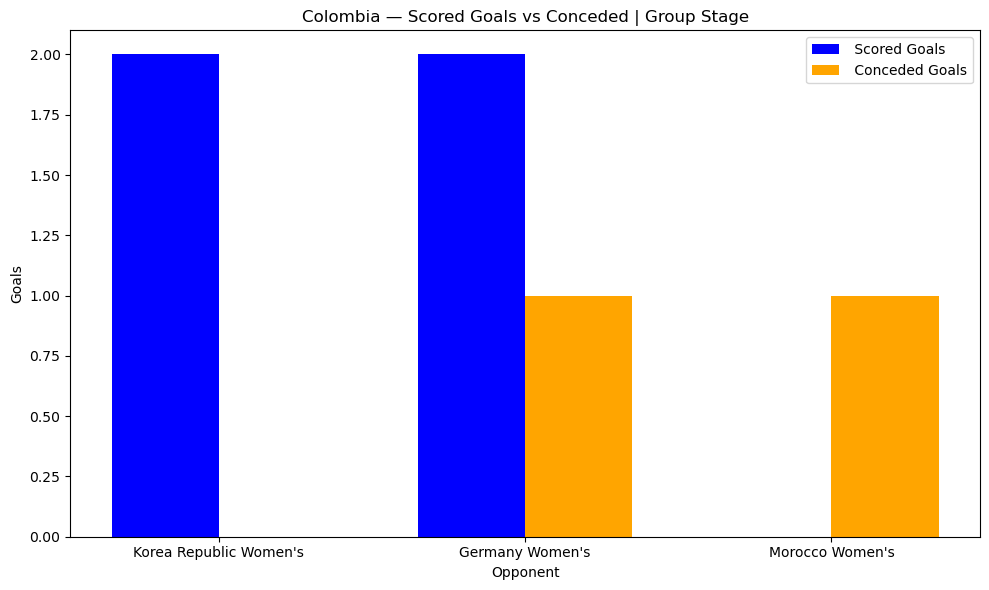

In [18]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Colombia Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Colombia — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

The Colombian team lost one game—against Morocco—and won two. 
In total, they scored 4 goals and allowed 2.

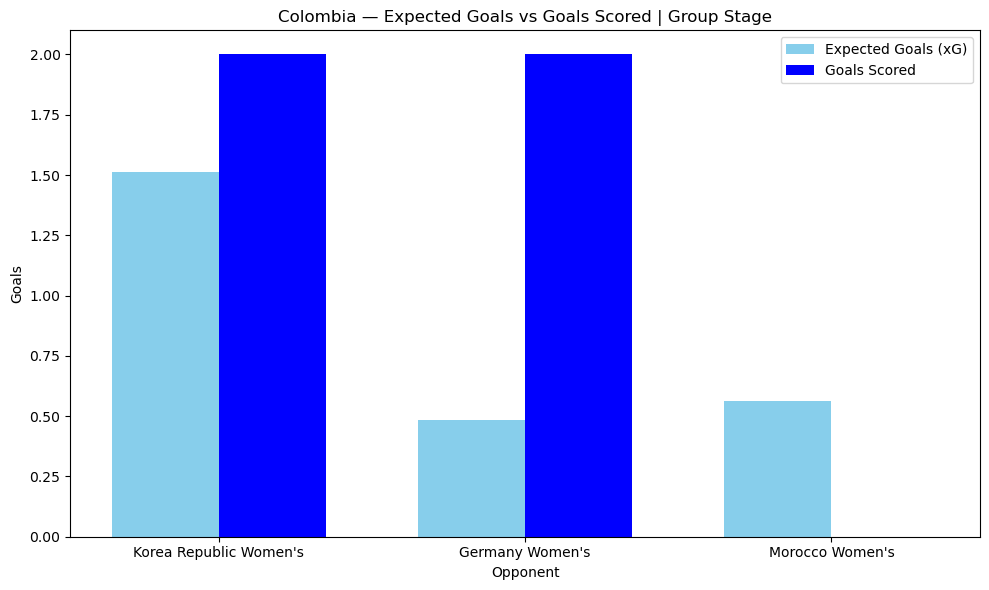

In [21]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Colombia Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Colombia — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

In the two games Colombia won, they outperformed their xG, which may indicate superior offensive performance. However, this was not the case in the game against Morocco, in which they did not score any goals and fell short of their xG.

# Analysis COL-KOR

In [27]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Colombia Women's") &
        (womens_world_cup_stats["opponent"] == "Korea Republic Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Korea Republic Women's") &
        (womens_world_cup_stats["opponent"] == "Colombia Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Colombia": [
        match.loc[
            match["team"] == "Colombia Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "South Korea": [
        match.loc[
            match["team"] == "Korea Republic Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Colombia", "South Korea"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Colombia", "South Korea"]
].round(1)


# Display table

comparison

,Metric,Colombia,South Korea
0,Goals,2.0,0.0
1,xG,1.5,0.3
2,Goals Minus xG,0.5,-0.3
3,Shots,17.0,5.0
4,Shots on Target,5.0,3.0
5,Saves,3.0,3.0
6,Possession %,59.1,40.9
7,Pass Accuracy %,71.7,60.2
8,Progressive Passes,97.0,71.0
9,Progressive Carries,12.0,11.0


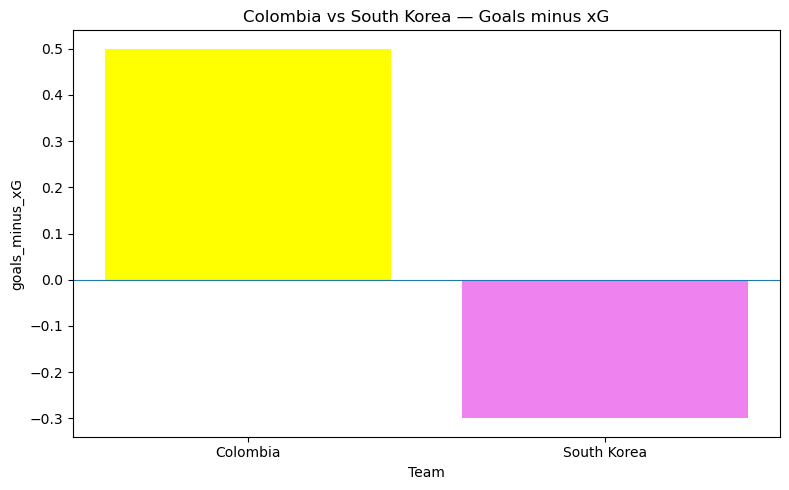

In [40]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Colombia Women's") &
        (womens_world_cup_stats["opponent"] == "Korea Republic Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Korea Republic Women's") &
        (womens_world_cup_stats["opponent"] == "Colombia Women's")
    )
].copy()


teams = ["Colombia", "South Korea"]

goals_minus_xG = [
    match.loc[match["team"] == "Colombia Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Korea Republic Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["yellow", "violet"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Colombia vs South Korea — Goals minus xG")

plt.tight_layout()
plt.show()

As seen above, Colombia outperformed its xG, scoring one more goal than expected. South Korea, meanwhile, failed to score a goal and fell short of its xG.

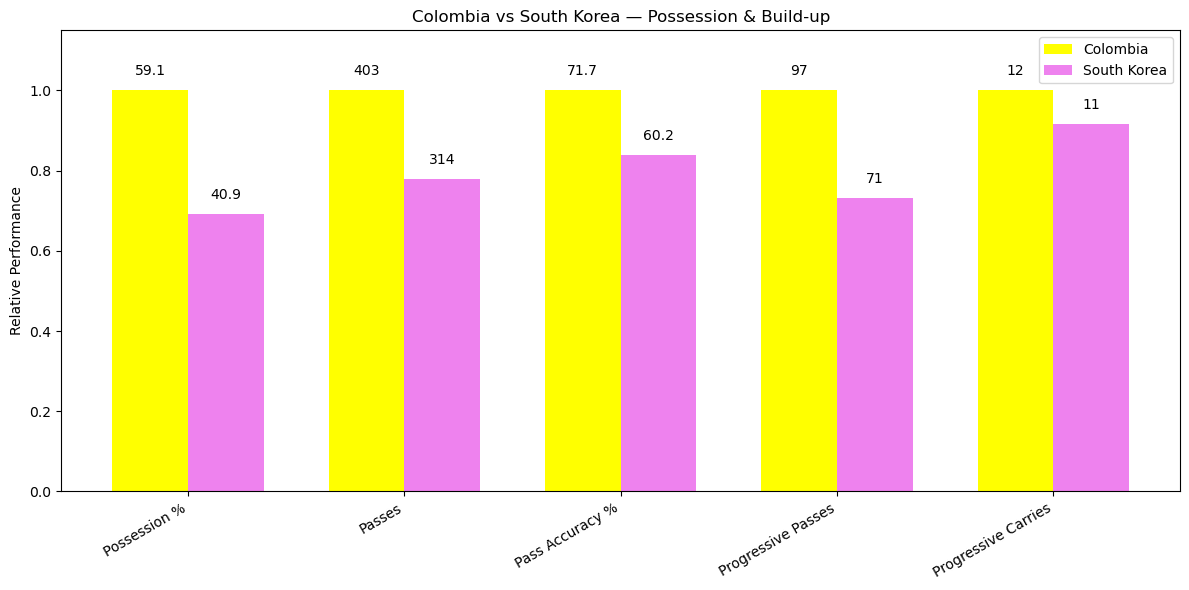

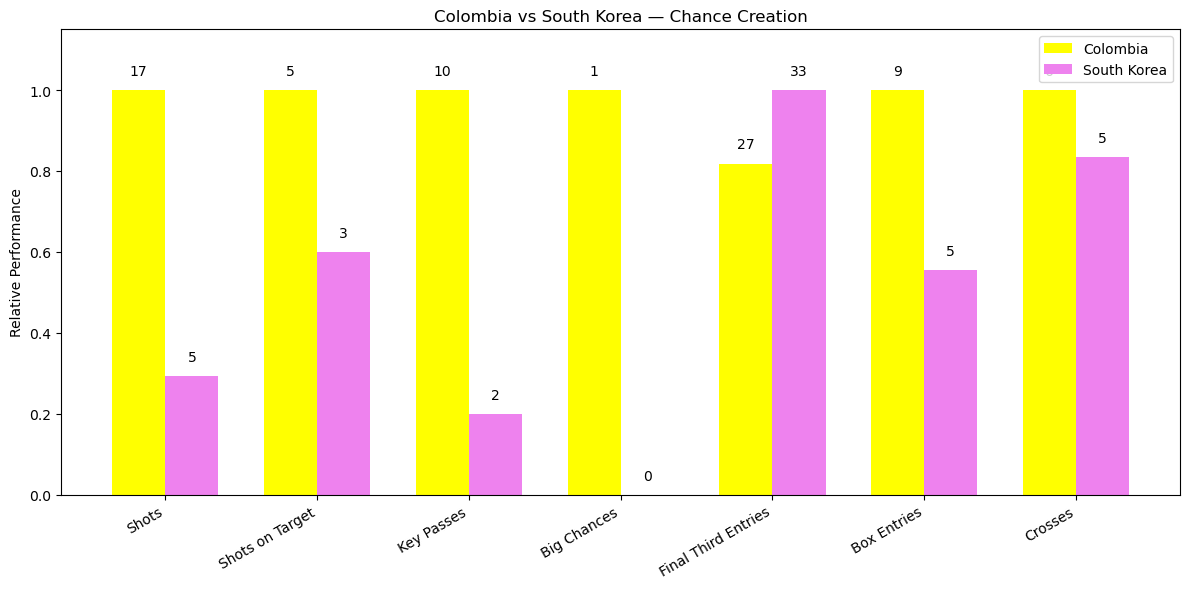

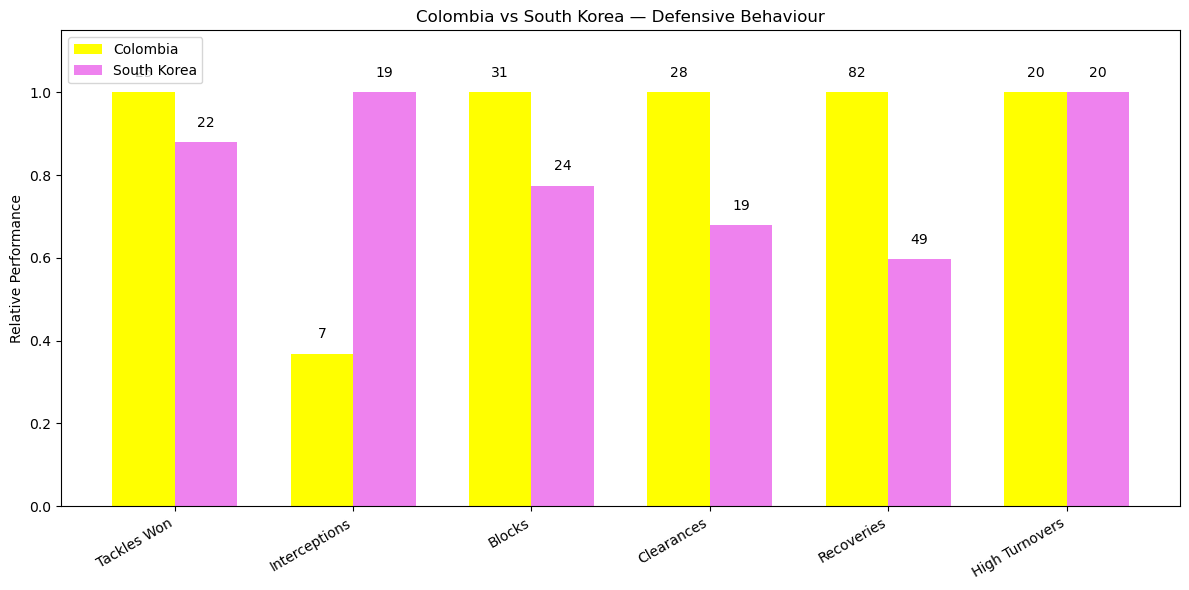

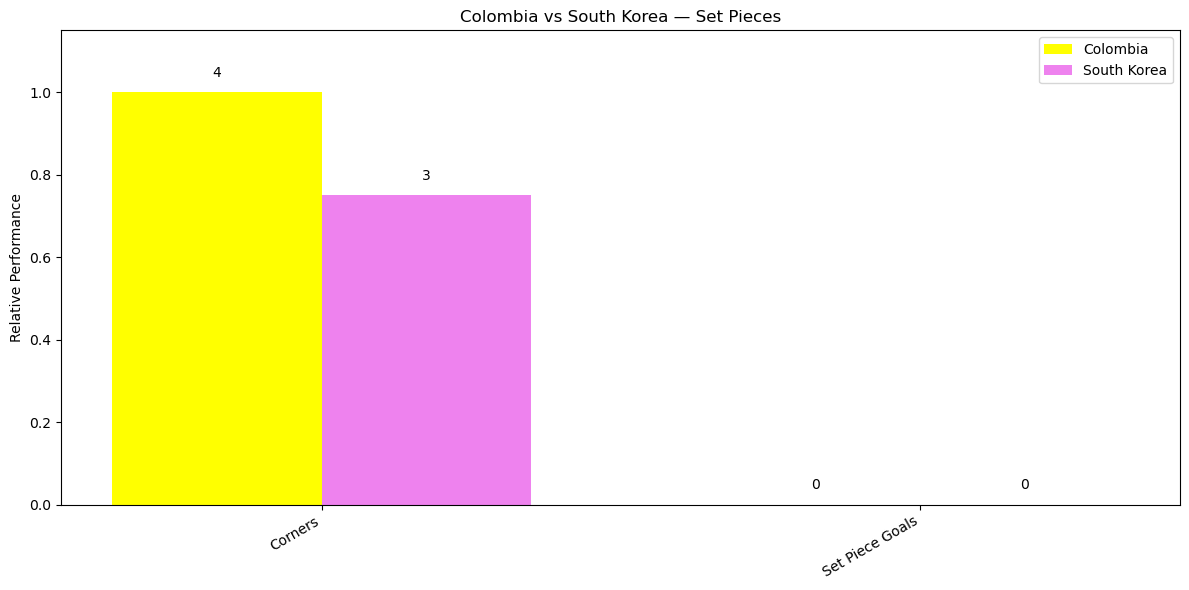

In [44]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Colombia Women's") &
        (womens_world_cup_stats["opponent"] == "Korea Republic Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Korea Republic Women's") &
        (womens_world_cup_stats["opponent"] == "Colombia Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Colombia": "Colombia Women's",
    "South Korea": "Korea Republic Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    col_values = np.array([
        match.loc[
            match["team"] == team_names["Colombia"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    kor_values = np.array([
        match.loc[
            match["team"] == team_names["South Korea"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(col_values, kor_values)

    # Normalize
    col_normalized = np.divide(
        col_values,
        max_values,
        out=np.zeros_like(col_values),
        where=max_values != 0
    )

    kor_normalized = np.divide(
        kor_values,
        max_values,
        out=np.zeros_like(kor_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_col = plt.bar(
        x - width / 2,
        col_normalized,
        width,
        label="Colombia",
        color="yellow"
    )

    bars_kor = plt.bar(
        x + width / 2,
        kor_normalized,
        width,
        label="South Korea",
        color="violet"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_col, col_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_kor, kor_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Colombia vs South Korea — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of COL-KOR

Colombia controlled much of the match and was clearly the more productive team, with more possession, shots, attacking runs, and xG. Still, South Korea showed tenacity and managed to maintain some competitiveness and territorial balance, particularly through their forays into the final third. The difference lay in Colombia’s ability to convert its dominance into chances and goals. Despite 17 shots, only 5 were on target, revealing some wastefulness in front of goal.

# Analysis COL-GER

In [49]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Colombia Women's") &
        (womens_world_cup_stats["opponent"] == "Germany Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Germany Women's") &
        (womens_world_cup_stats["opponent"] == "Colombia Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Colombia": [
        match.loc[
            match["team"] == "Colombia Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Germany": [
        match.loc[
            match["team"] == "Germany Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Colombia", "Germany"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Colombia", "Germany"]
].round(1)


# Display table

comparison

,Metric,Colombia,Germany
0,Goals,2.0,1.0
1,xG,0.5,1.5
2,Goals Minus xG,1.5,-0.5
3,Shots,9.0,14.0
4,Shots on Target,4.0,2.0
5,Saves,1.0,3.0
6,Possession %,42.1,57.9
7,Pass Accuracy %,61.1,79.3
8,Progressive Passes,85.0,146.0
9,Progressive Carries,12.0,17.0


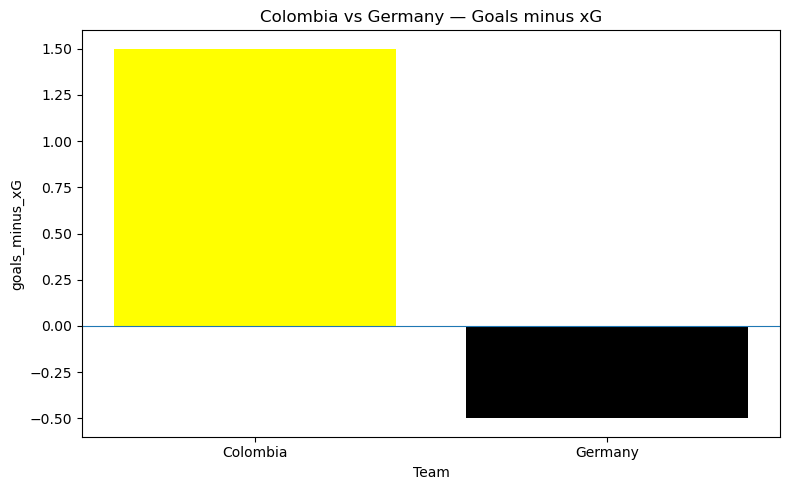

In [51]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Colombia Women's") &
        (womens_world_cup_stats["opponent"] == "Germany Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Germany Women's") &
        (womens_world_cup_stats["opponent"] == "Colombia Women's")
    )
].copy()


teams = ["Colombia", "Germany"]

goals_minus_xG = [
    match.loc[match["team"] == "Colombia Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Germany Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["yellow", "black"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Colombia vs Germany — Goals minus xG")

plt.tight_layout()
plt.show()

This graph is very interesting. It shows a positive xG minus goals, which suggests that Colombia was not expected to score more goals than usual; Germany, on the other hand, has a negative xG minus goals, indicating that it failed to exceed expectations.
This demonstrates Colombia’s ability to overcome obstacles in unexpected ways.

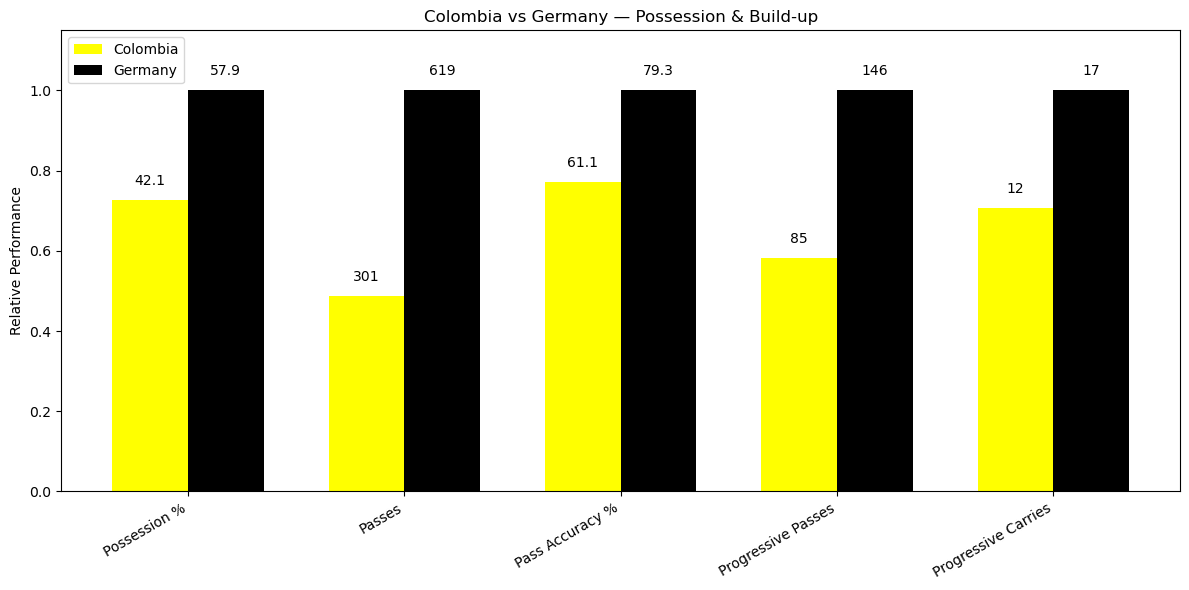

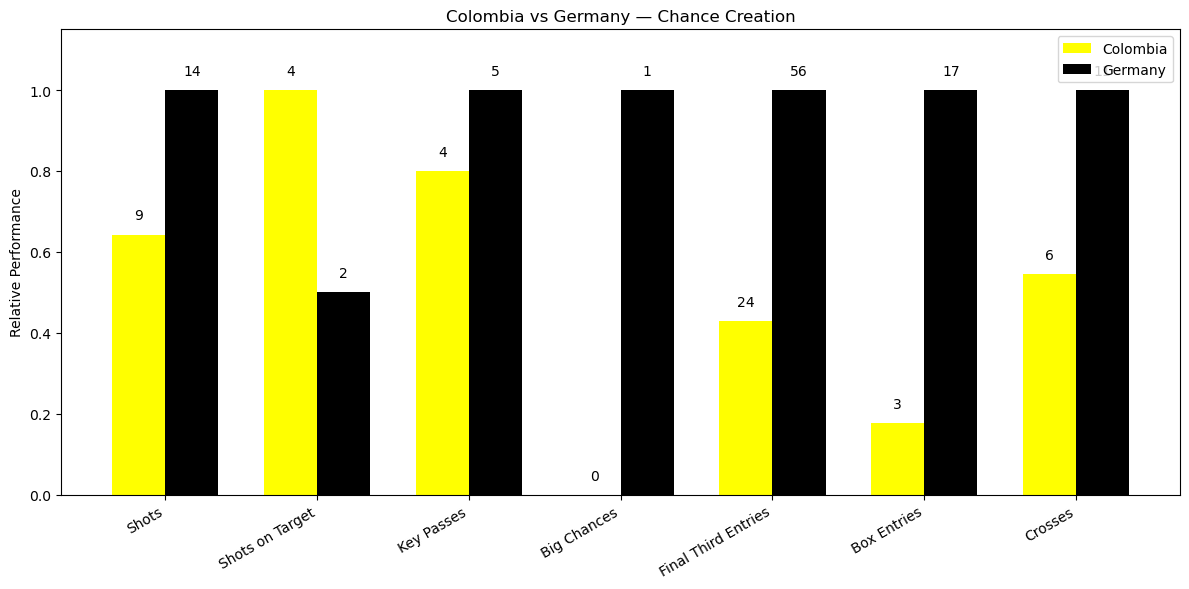

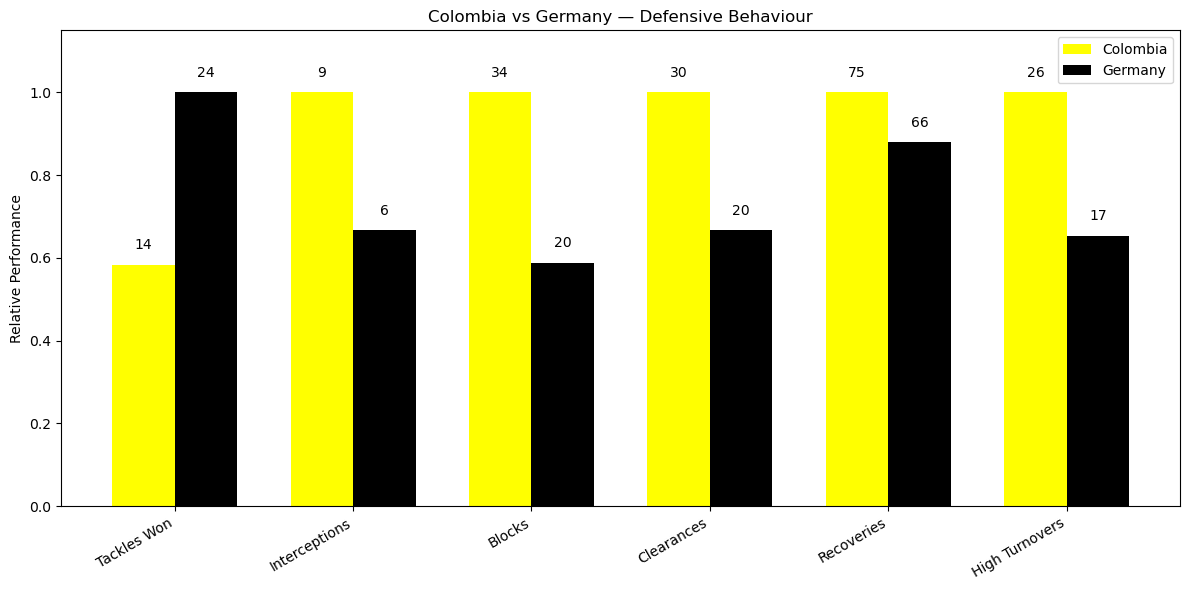

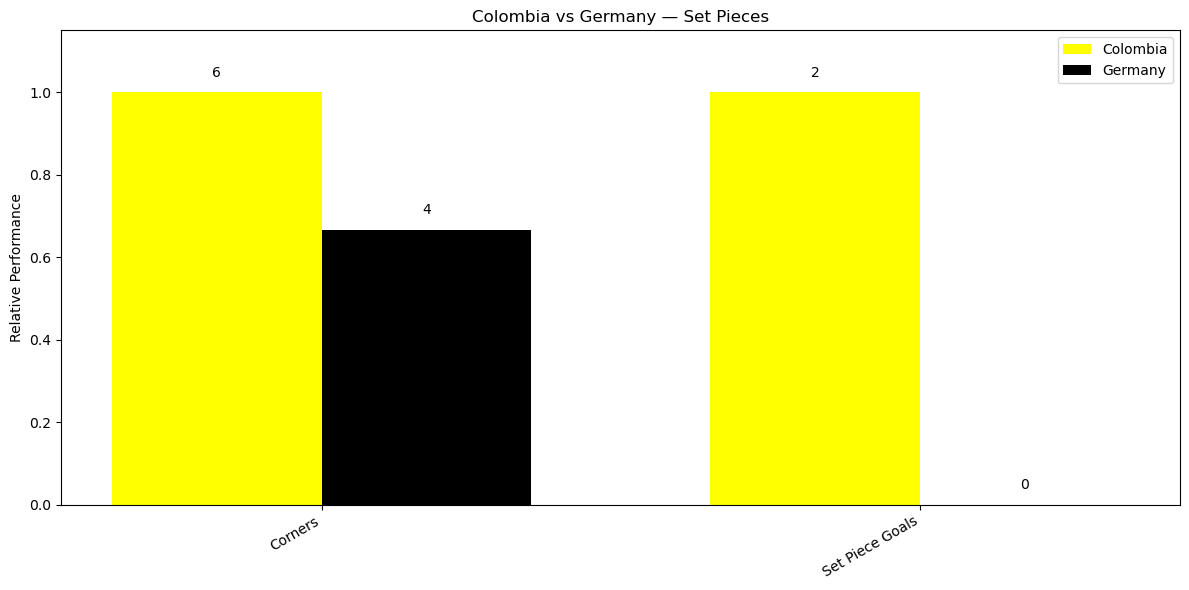

In [54]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Colombia Women's") &
        (womens_world_cup_stats["opponent"] == "Germany Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Germany Women's") &
        (womens_world_cup_stats["opponent"] == "Colombia Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Colombia": "Colombia Women's",
    "Germany": "Germany Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    col_values = np.array([
        match.loc[
            match["team"] == team_names["Colombia"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    ger_values = np.array([
        match.loc[
            match["team"] == team_names["Germany"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(col_values, ger_values)

    # Normalize
    col_normalized = np.divide(
        col_values,
        max_values,
        out=np.zeros_like(col_values),
        where=max_values != 0
    )

    ger_normalized = np.divide(
        ger_values,
        max_values,
        out=np.zeros_like(ger_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_col = plt.bar(
        x - width / 2,
        col_normalized,
        width,
        label="Colombia",
        color="yellow"
    )

    bars_ger = plt.bar(
        x + width / 2,
        ger_normalized,
        width,
        label="Germany",
        color="black"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_col, col_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_ger, ger_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Colombia vs Germany — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

#### Correção de um erro no dataset 

In [68]:
womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Colombia Women's") &
        (womens_world_cup_stats["opponent"] == "Germany Women's")
    )
][
    ["team", "opponent", "stage", "goals_for", "set_piece_goals"]
]

,team,opponent,stage,goals_for,set_piece_goals
62,Colombia Women's,Germany Women's,Group,2,2


In [76]:
print([col for col in womens_world_cup_stats.columns if "set_piece" in col.lower()])

['set_piece_goals']


In [92]:
womens_world_cup_stats.loc[
    (womens_world_cup_stats["team"] == "Colombia Women's") &
    (womens_world_cup_stats["opponent"] == "Germany Women's"),
    "set_piece_goals"
] = 1

In [95]:
womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Colombia Women's") &
    (womens_world_cup_stats["opponent"] == "Germany Women's")
][
    ["team", "opponent", "set_piece_goals"]
]

,team,opponent,set_piece_goals
62,Colombia Women's,Germany Women's,1


## Conclusion COL-GER

Germany dominated the game in terms of possession, build-up play, and territorial control, recording 57.9% possession, 146 progressive passes, and 17 entries into the box, compared to just 3 by Colombia. However, Colombia was far more efficient in front of goal: it scored twice on just 0.5 xG, while Germany, despite generating 1.5 xG, scored only one goal. The result therefore seems to reflect Colombia’s efficiency more than its dominance of the game, with a clear discrepancy between the quality of play and the final outcome.

# Analysis COL-MOR

In [100]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Colombia Women's") &
        (womens_world_cup_stats["opponent"] == "Morocco Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Morocco Women's") &
        (womens_world_cup_stats["opponent"] == "Colombia Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Colombia": [
        match.loc[
            match["team"] == "Colombia Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Morocco": [
        match.loc[
            match["team"] == "Morocco Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Colombia", "Morocco"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Colombia", "Morocco"]
].round(1)


# Display table

comparison

,Metric,Colombia,Morocco
0,Goals,0.0,1.0
1,xG,0.6,1.7
2,Goals Minus xG,-0.6,-0.7
3,Shots,11.0,8.0
4,Shots on Target,4.0,6.0
5,Saves,5.0,4.0
6,Possession %,58.7,41.3
7,Pass Accuracy %,78.3,61.4
8,Progressive Passes,113.0,79.0
9,Progressive Carries,10.0,20.0


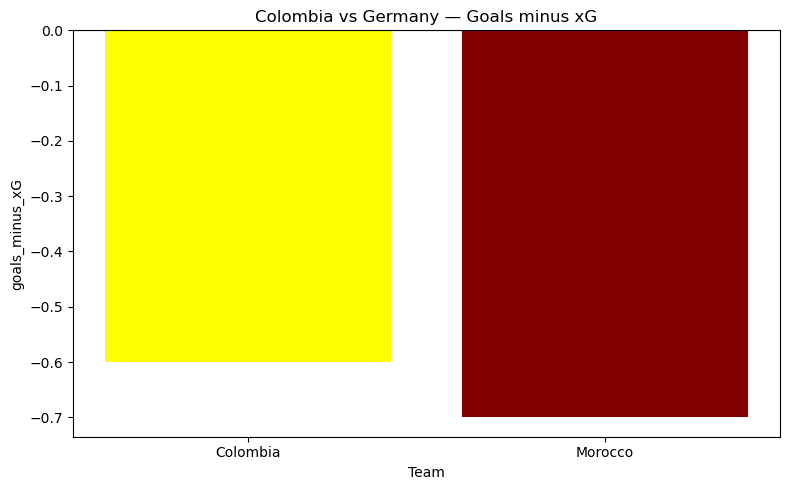

In [104]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Colombia Women's") &
        (womens_world_cup_stats["opponent"] == "Morocco Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Morocco Women's") &
        (womens_world_cup_stats["opponent"] == "Colombia Women's")
    )
].copy()


teams = ["Colombia", "Morocco"]

goals_minus_xG = [
    match.loc[match["team"] == "Colombia Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Morocco Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["yellow", "maroon"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Colombia vs Germany — Goals minus xG")

plt.tight_layout()
plt.show()

Neither team managed to exceed their xG, scoring fewer goals than would be expected given the chances they created.

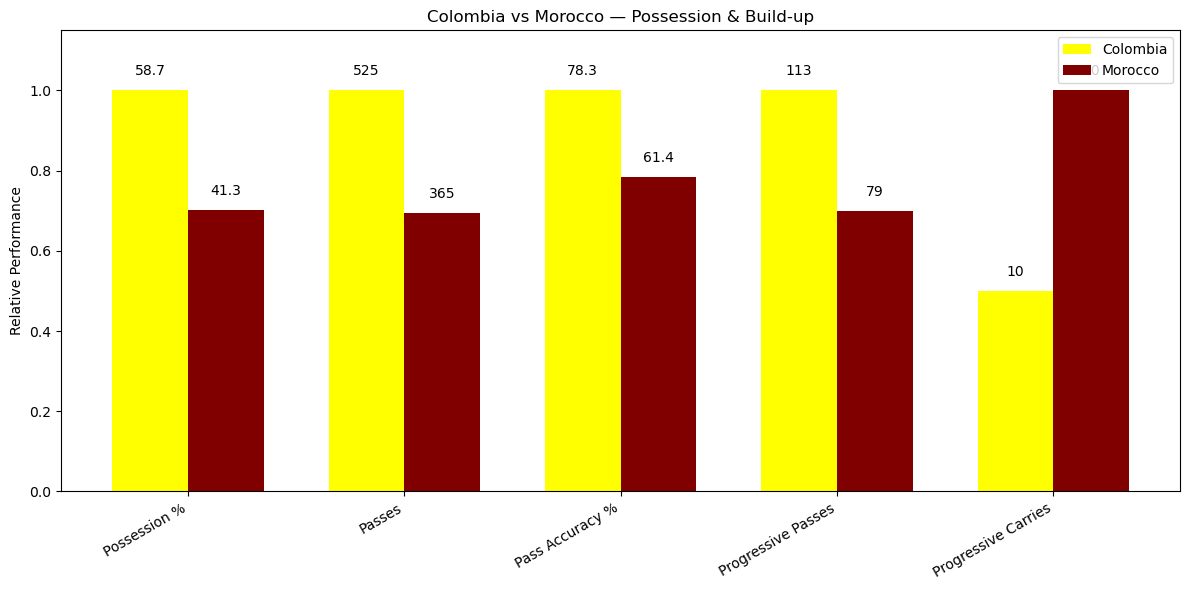

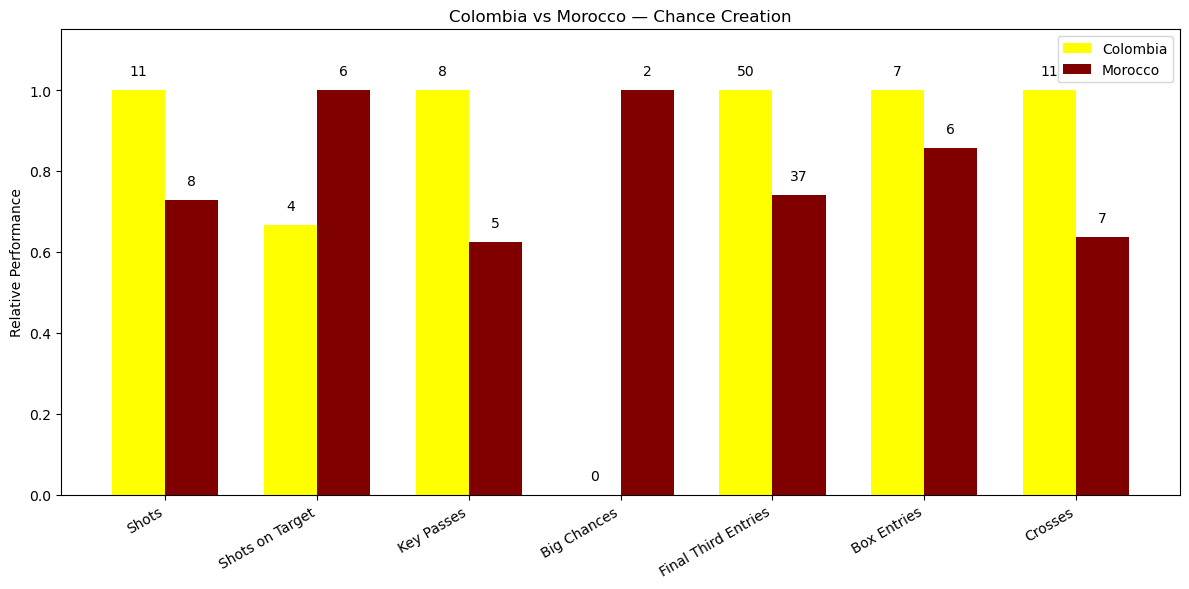

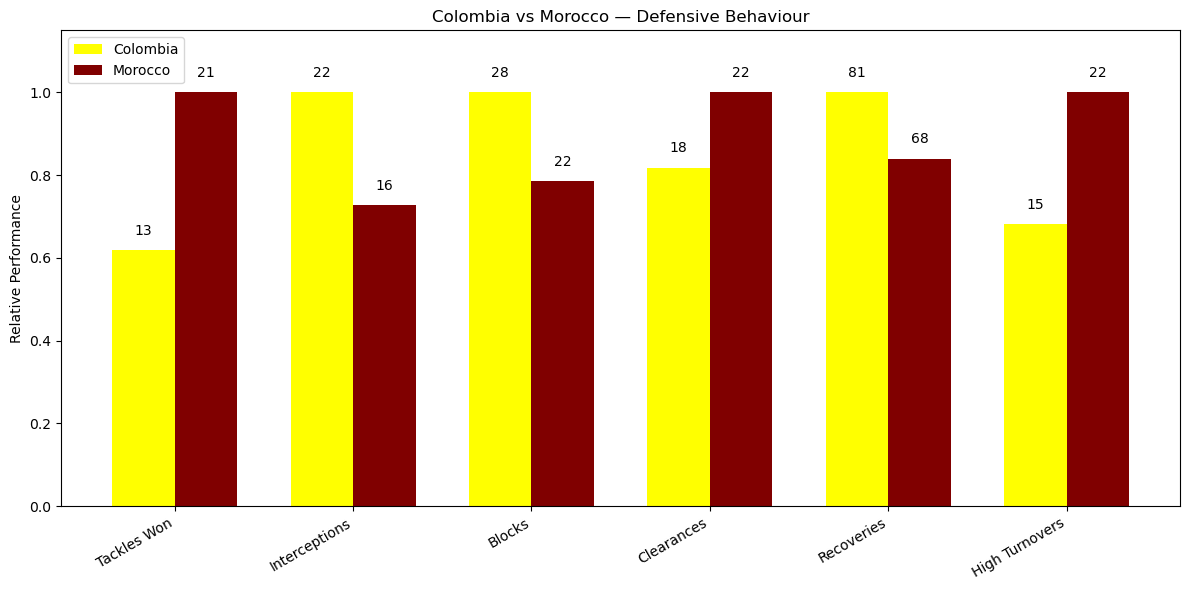

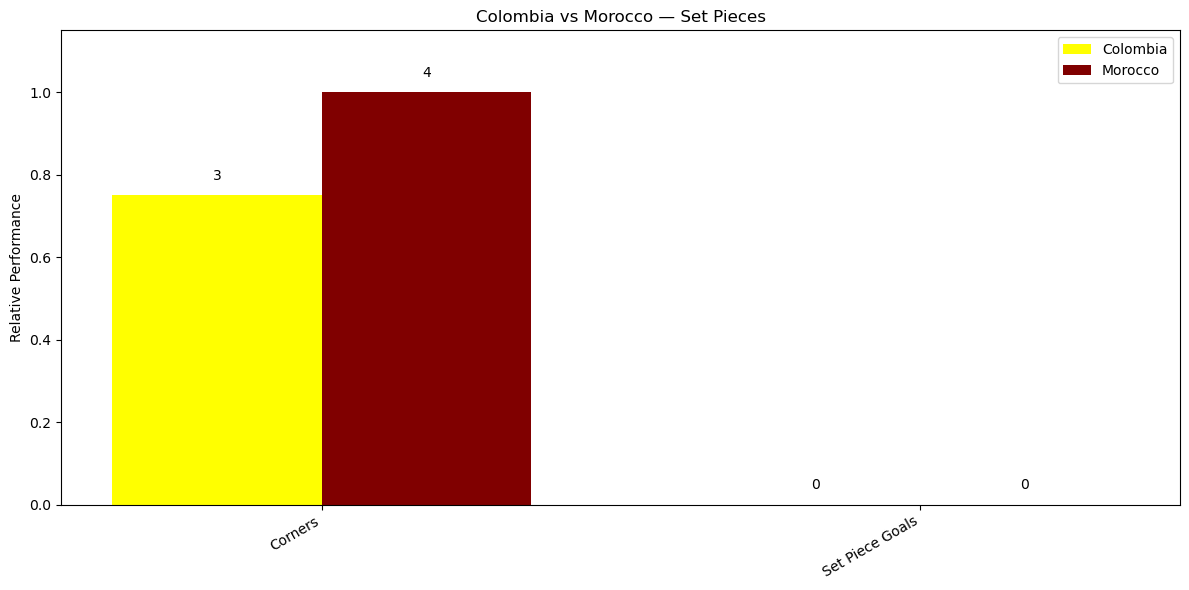

In [110]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Colombia Women's") &
        (womens_world_cup_stats["opponent"] == "Morocco Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Morocco Women's") &
        (womens_world_cup_stats["opponent"] == "Colombia Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Colombia": "Colombia Women's",
    "Morocco": "Morocco Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    col_values = np.array([
        match.loc[
            match["team"] == team_names["Colombia"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    mor_values = np.array([
        match.loc[
            match["team"] == team_names["Morocco"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(col_values, mor_values)

    # Normalize
    col_normalized = np.divide(
        col_values,
        max_values,
        out=np.zeros_like(col_values),
        where=max_values != 0
    )

    mor_normalized = np.divide(
        mor_values,
        max_values,
        out=np.zeros_like(mor_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_col = plt.bar(
        x - width / 2,
        col_normalized,
        width,
        label="Colombia",
        color="yellow"
    )

    bars_mor = plt.bar(
        x + width / 2,
        mor_normalized,
        width,
        label="Morocco",
        color="maroon"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_col, col_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_mor, mor_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Colombia vs Morocco — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion COL-MOR

Colombia controlled possession more and had greater ball movement and presence in the final third, but Morocco was more dangerous and efficient in its use of the ball. With less possession and fewer shots, it created nearly three times as much xG (1.7 vs. 0.6) and had more shots on goal (6 vs. 4). Defensively, the two teams were evenly matched, though with different styles: Colombia stood out for its interceptions and ball recoveries, while Morocco recorded more tackles won and clearances.

# Analysis Morocco's Group Stage games

In [116]:
team = "Morocco Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
24,3893799,Germany Women's,Morocco Women's,Group
25,3893799,Morocco Women's,Germany Women's,Group
64,3893819,Korea Republic Women's,Morocco Women's,Group
65,3893819,Morocco Women's,Korea Republic Women's,Group
94,3893834,Colombia Women's,Morocco Women's,Group
95,3893834,Morocco Women's,Colombia Women's,Group


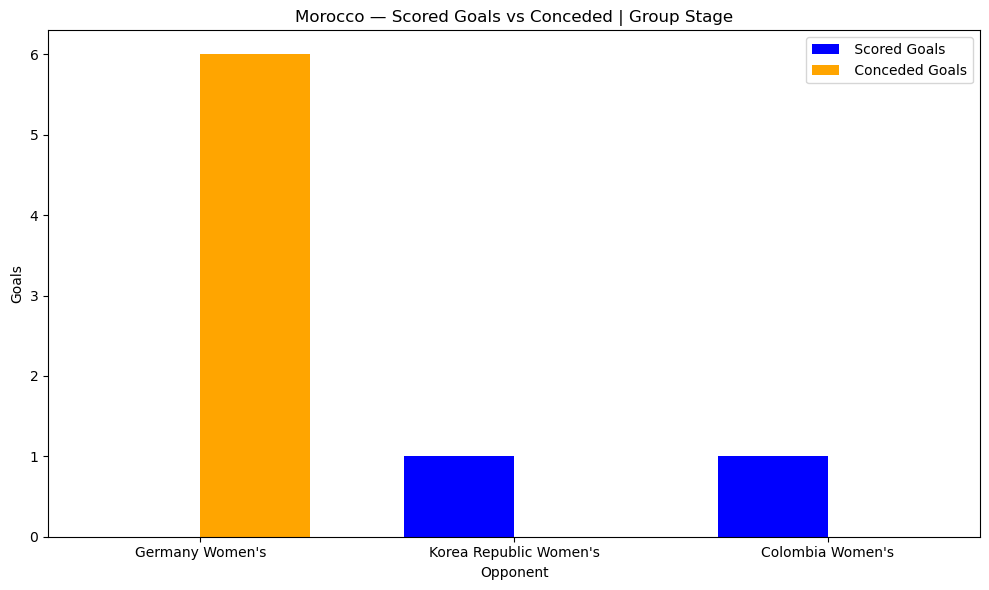

In [118]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Morocco Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Morocco — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Morocco won 2 games and lost 1. They scored 2 goals but conceded 6, which shows inconsistency on the team's part.

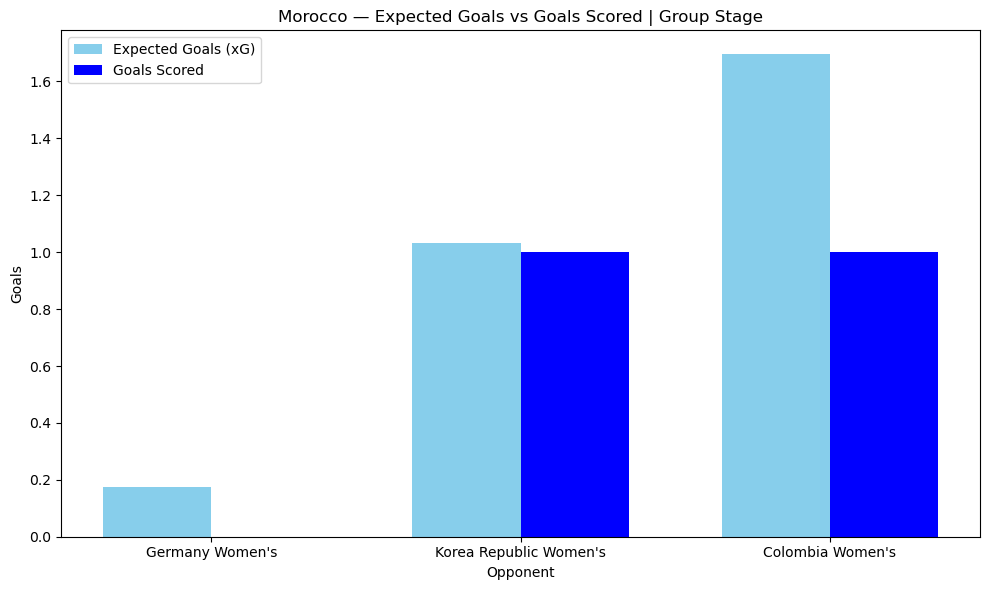

In [123]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Morocco Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Morocco — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

As for xG, the North African team consistently fell short of expectations; despite winning two games, it has shown a lack of finishing ability.

# Analysis MOR-GER

In [128]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Morocco Women's") &
        (womens_world_cup_stats["opponent"] == "Germany Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Germany Women's") &
        (womens_world_cup_stats["opponent"] == "Morocco Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Morocco": [
        match.loc[
            match["team"] == "Morocco Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Germany": [
        match.loc[
            match["team"] == "Germany Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Morocco", "Germany"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Morocco", "Germany"]
].round(1)


# Display table

comparison

,Metric,Morocco,Germany
0,Goals,0.0,6.0
1,xG,0.2,2.3
2,Goals Minus xG,-0.2,1.7
3,Shots,6.0,16.0
4,Shots on Target,4.0,6.0
5,Saves,3.0,4.0
6,Possession %,29.7,70.3
7,Pass Accuracy %,62.8,85.1
8,Progressive Passes,70.0,138.0
9,Progressive Carries,8.0,22.0


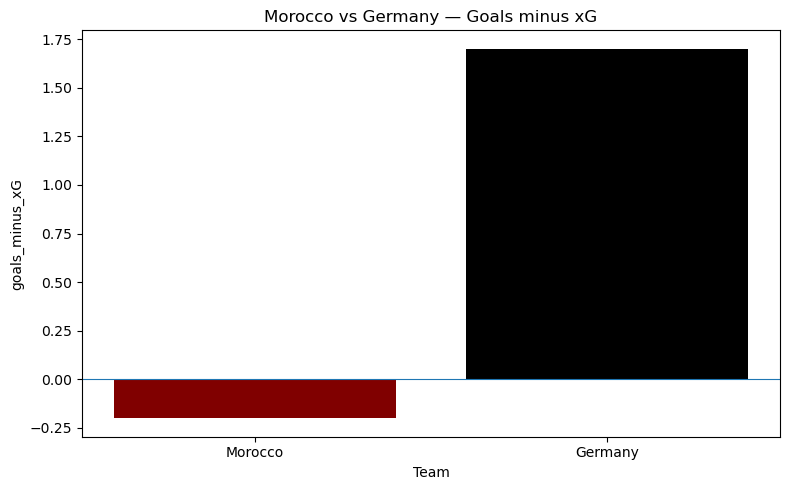

In [130]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Morocco Women's") &
        (womens_world_cup_stats["opponent"] == "Germany Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Germany Women's") &
        (womens_world_cup_stats["opponent"] == "Morocco Women's")
    )
].copy()


teams = ["Morocco", "Germany"]

goals_minus_xG = [
    match.loc[match["team"] == "Morocco Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Germany Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["maroon", "black"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Morocco vs Germany — Goals minus xG")

plt.tight_layout()
plt.show()

Germany had an xG of 1.7 and managed to exceed it by scoring more goals than the opportunities projected. Given some of the statistics presented in the previous table, this result goes a long way toward explaining the team’s position. Morocco, on the other hand, showed the opposite, posting a negative xG minus goals.

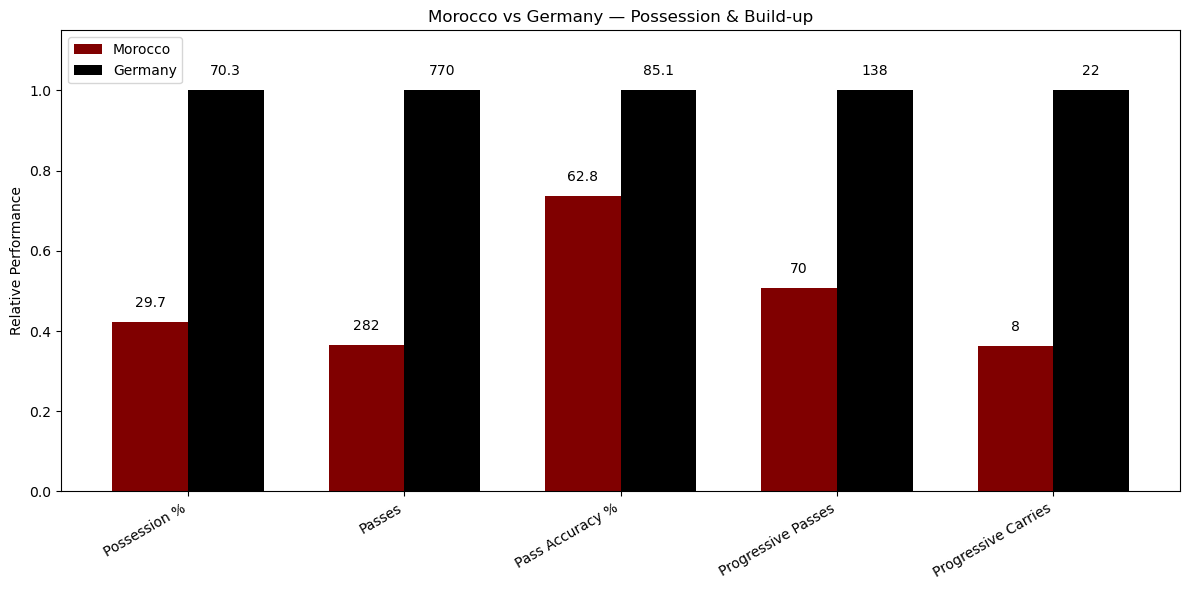

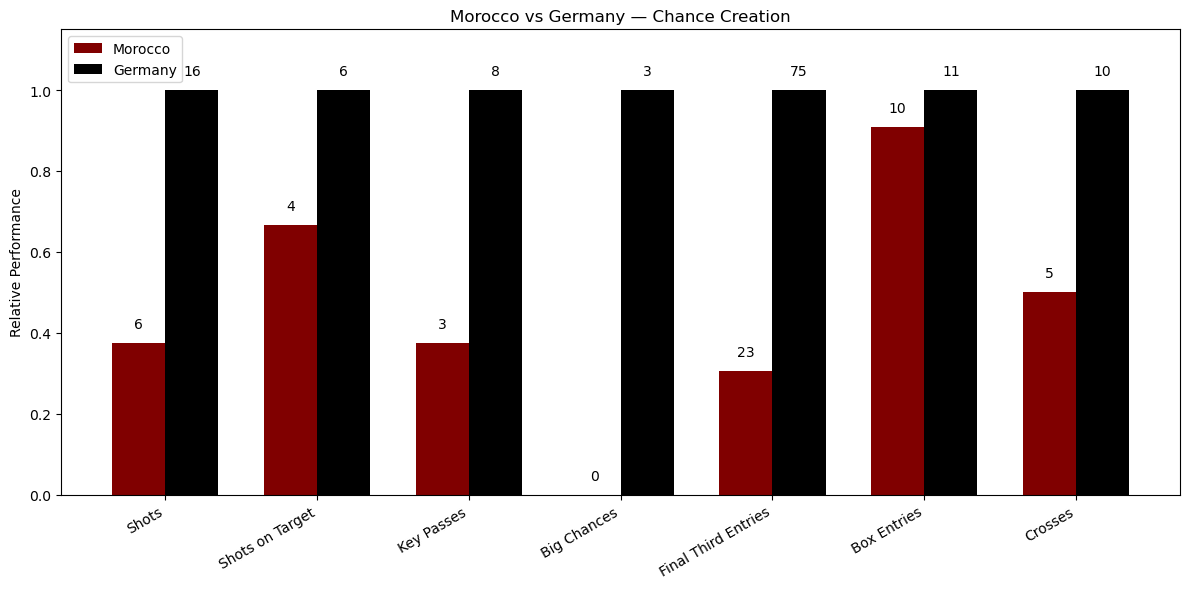

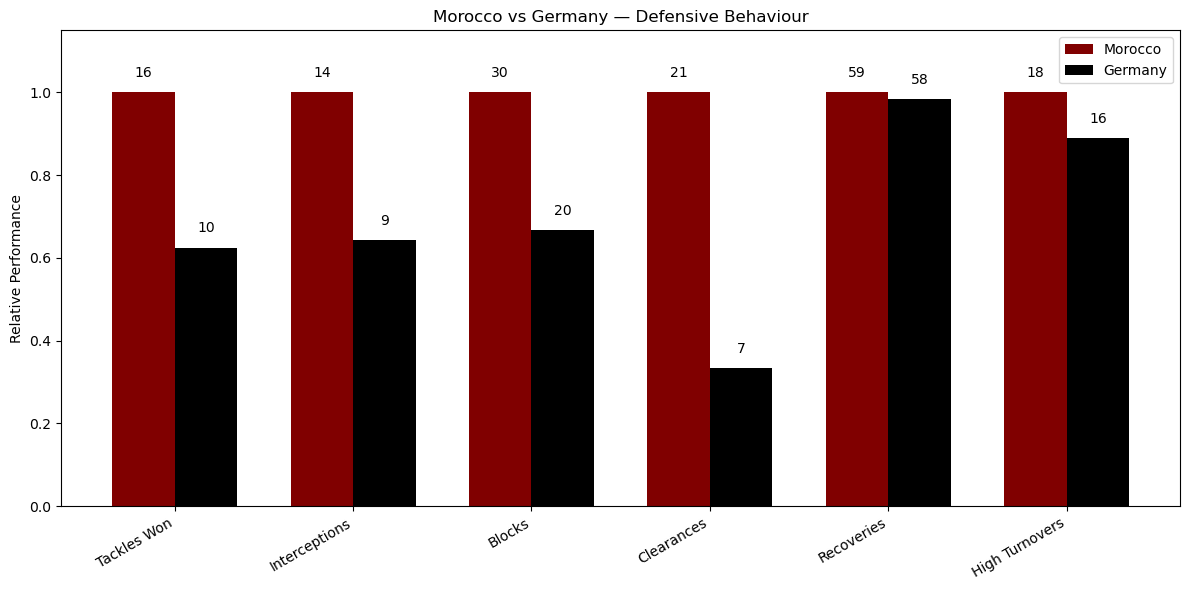

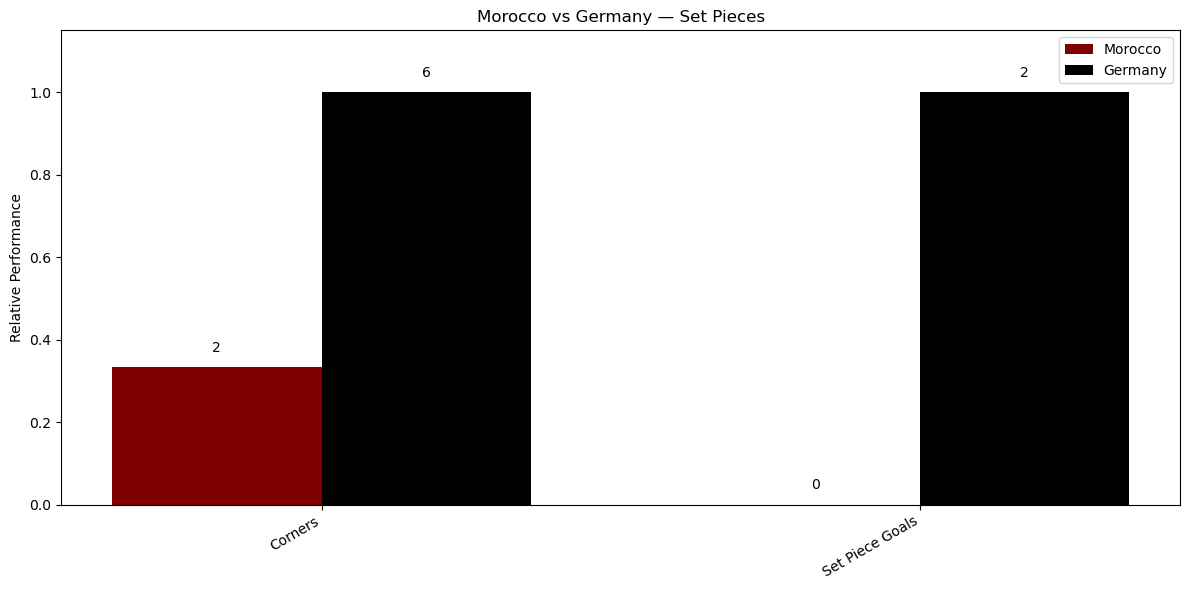

In [139]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Morocco Women's") &
        (womens_world_cup_stats["opponent"] == "Germany Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Germany Women's") &
        (womens_world_cup_stats["opponent"] == "Morocco Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Morocco": "Morocco Women's",
    "Germany": "Germany Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    mor_values = np.array([
        match.loc[
            match["team"] == team_names["Morocco"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    ger_values = np.array([
        match.loc[
            match["team"] == team_names["Germany"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(mor_values, ger_values)

    # Normalize
    mor_normalized = np.divide(
        mor_values,
        max_values,
        out=np.zeros_like(mor_values),
        where=max_values != 0
    )

    ger_normalized = np.divide(
        ger_values,
        max_values,
        out=np.zeros_like(ger_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_mor = plt.bar(
        x - width / 2,
        mor_normalized,
        width,
        label="Morocco",
        color="maroon"
    )

    bars_ger = plt.bar(
        x + width / 2,
        ger_normalized,
        width,
        label="Germany",
        color="black"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_mor, mor_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_ger, ger_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Morocco vs Germany — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion MOR-GER

Germany completely dominated the match, controlling possession, ball progression, and attacking territory, while keeping Morocco under constant pressure. The 75 final-third entries compared to 23, and the 138 progressive passes compared to 70, demonstrate the extent of that dominance. Morocco’s numerous defensive actions—such as blocks, clearances, and interceptions—appear to have been primarily a response to Germany’s offensive volume, reflecting the amount of time the team spent defending. Although Germany recorded 16 shots, only 6 were on target; however, the team was extremely efficient in converting chances, scoring 6 goals from 2.3 xG.

# Analysis MOR-KOR

In [144]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Morocco Women's") &
        (womens_world_cup_stats["opponent"] == "Korea Republic Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Korea Republic Women's") &
        (womens_world_cup_stats["opponent"] == "Morocco Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Morocco": [
        match.loc[
            match["team"] == "Morocco Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "South Korea": [
        match.loc[
            match["team"] == "Korea Republic Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Morocco", "South Korea"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Morocco", "South Korea"]
].round(1)


# Display table

comparison

,Metric,Morocco,South Korea
0,Goals,1.0,0.0
1,xG,1.0,1.4
2,Goals Minus xG,-0.0,-1.4
3,Shots,10.0,17.0
4,Shots on Target,2.0,0.0
5,Saves,0.0,1.0
6,Possession %,34.7,65.3
7,Pass Accuracy %,64.6,75.3
8,Progressive Passes,91.0,136.0
9,Progressive Carries,22.0,17.0


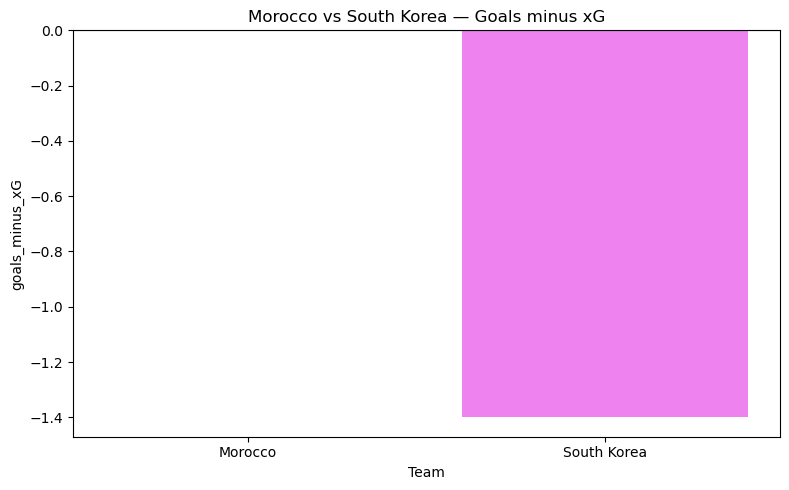

In [148]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Morocco Women's") &
        (womens_world_cup_stats["opponent"] == "Korea Republic Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Korea Republic Women's") &
        (womens_world_cup_stats["opponent"] == "Morocco Women's")
    )
].copy()


teams = ["Morocco", "South Korea"]

goals_minus_xG = [
    match.loc[match["team"] == "Morocco Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Korea Republic Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["maroon", "violet"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Morocco vs South Korea — Goals minus xG")

plt.tight_layout()
plt.show()

Morocco performed exactly as expected in the game, scoring 1 goal. Korea, on the other hand, had an xG of 1.4, and since it didn't score any goals, they fell behind expectations. 

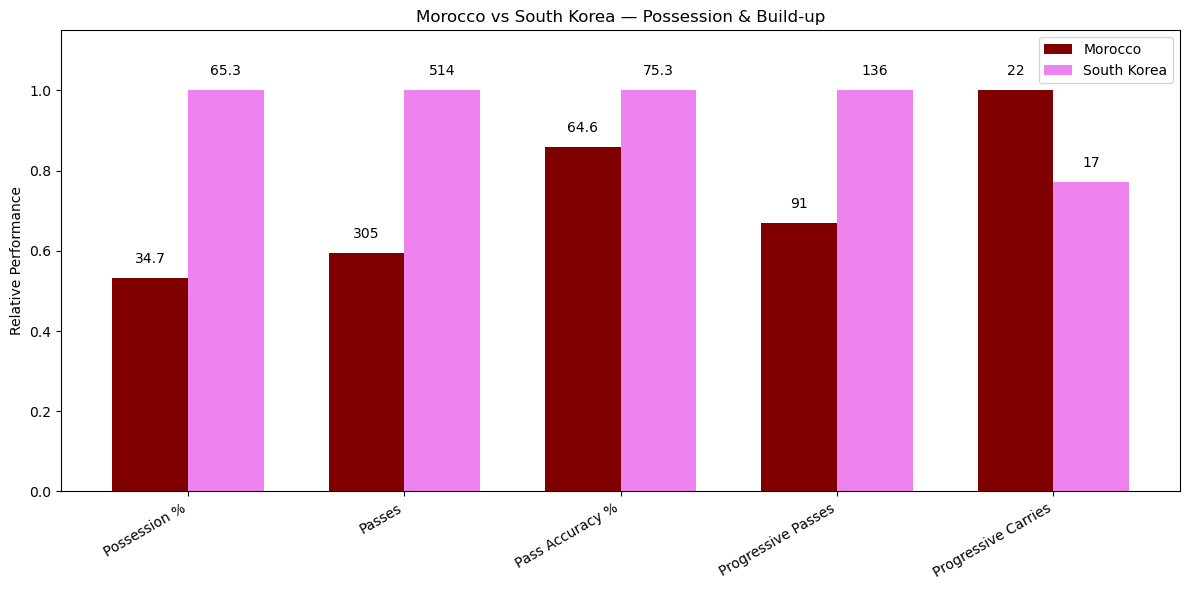

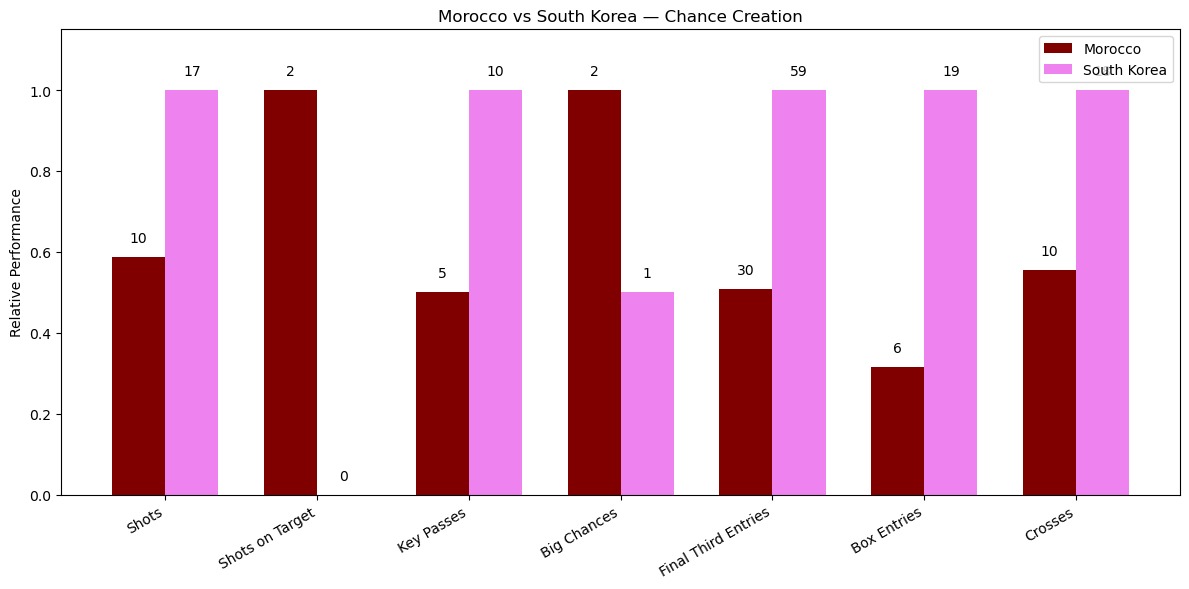

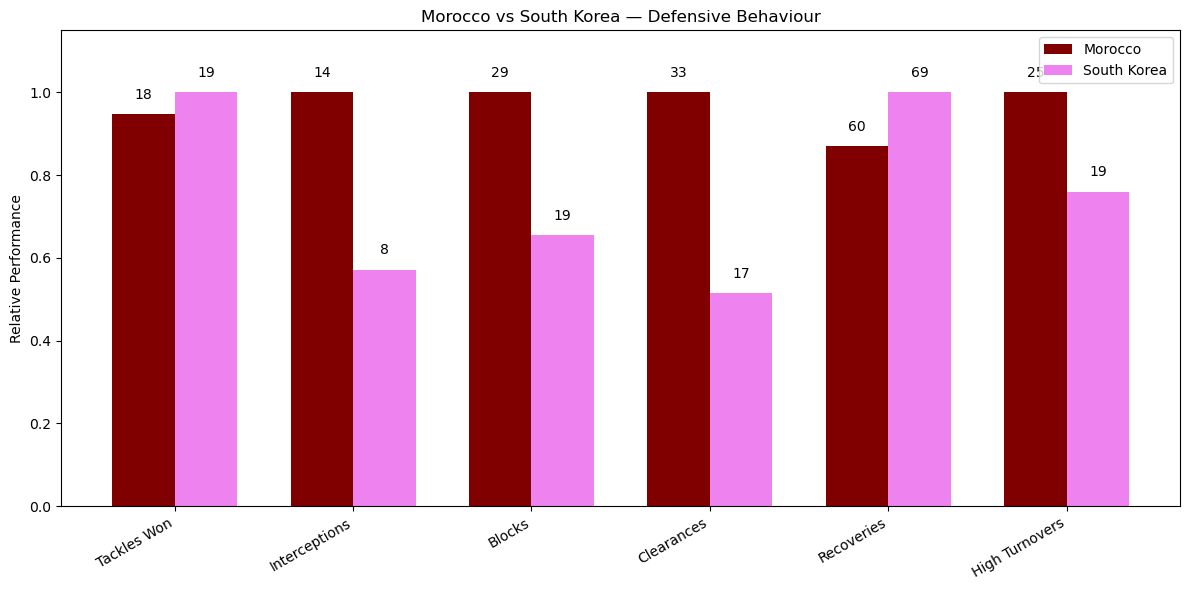

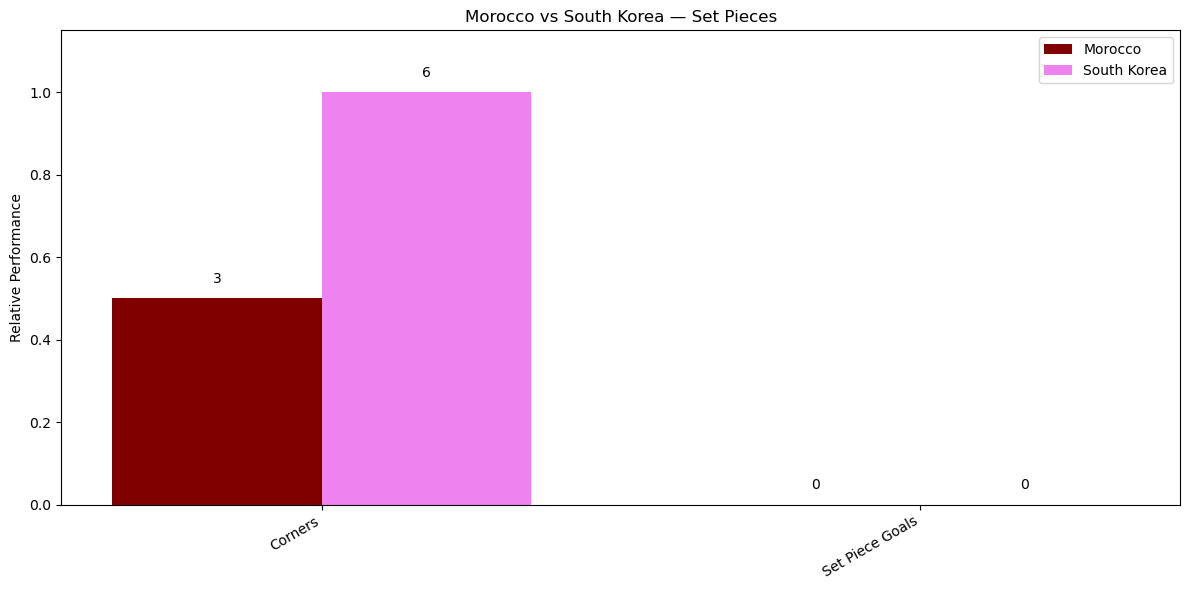

In [158]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Morocco Women's") &
        (womens_world_cup_stats["opponent"] == "Korea Republic Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Korea Republic Women's") &
        (womens_world_cup_stats["opponent"] == "Morocco Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Morocco": "Morocco Women's",
    "South Korea": "Korea Republic Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    mor_values = np.array([
        match.loc[
            match["team"] == team_names["Morocco"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    kor_values = np.array([
        match.loc[
            match["team"] == team_names["South Korea"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(mor_values, kor_values)

    # Normalize
    mor_normalized = np.divide(
        mor_values,
        max_values,
        out=np.zeros_like(mor_values),
        where=max_values != 0
    )

    kor_normalized = np.divide(
        kor_values,
        max_values,
        out=np.zeros_like(kor_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_mor = plt.bar(
        x - width / 2,
        mor_normalized,
        width,
        label="Morocco",
        color="maroon"
    )

    bars_kor = plt.bar(
        x + width / 2,
        kor_normalized,
        width,
        label="South Korea",
        color="violet"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_mor, mor_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_kor, kor_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Morocco vs South Korea — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

#### Correção de um erro do dataset 

In [154]:
womens_world_cup_stats.loc[
    (womens_world_cup_stats["team"] == "Morocco Women's") &
    (womens_world_cup_stats["opponent"] == "Korea Republic Women's"),
    "set_piece_goals"
] = 0

In [156]:
womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Morocco Women's") &
    (womens_world_cup_stats["opponent"] == "Korea Republic Women's")
][
    ["team", "opponent", "stage", "set_piece_goals"]
]

,team,opponent,stage,set_piece_goals
65,Morocco Women's,Korea Republic Women's,Group,0


## Conclusion MOR-KOR

South Korea dominated much of the match in terms of possession and build-up play, reaching the final third and the opponent’s penalty area much more frequently. However, this territorial dominance did not translate into offensive effectiveness: despite 17 shots and 1.4 xG, they failed to register a single shot on goal. Morocco, on the other hand, had far less possession and offensive presence, but was able to capitalize on one of its chances and successfully defend its lead. The game highlights the difference between territorial control and finishing efficiency: South Korea had more control, but Morocco was more efficient with the chances it created.

# Analysis Germany's Group Stage games

In [165]:
team = "Germany Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
24,3893799,Germany Women's,Morocco Women's,Group
25,3893799,Morocco Women's,Germany Women's,Group
62,3893818,Colombia Women's,Germany Women's,Group
63,3893818,Germany Women's,Colombia Women's,Group
92,3893833,Germany Women's,Korea Republic Women's,Group
93,3893833,Korea Republic Women's,Germany Women's,Group


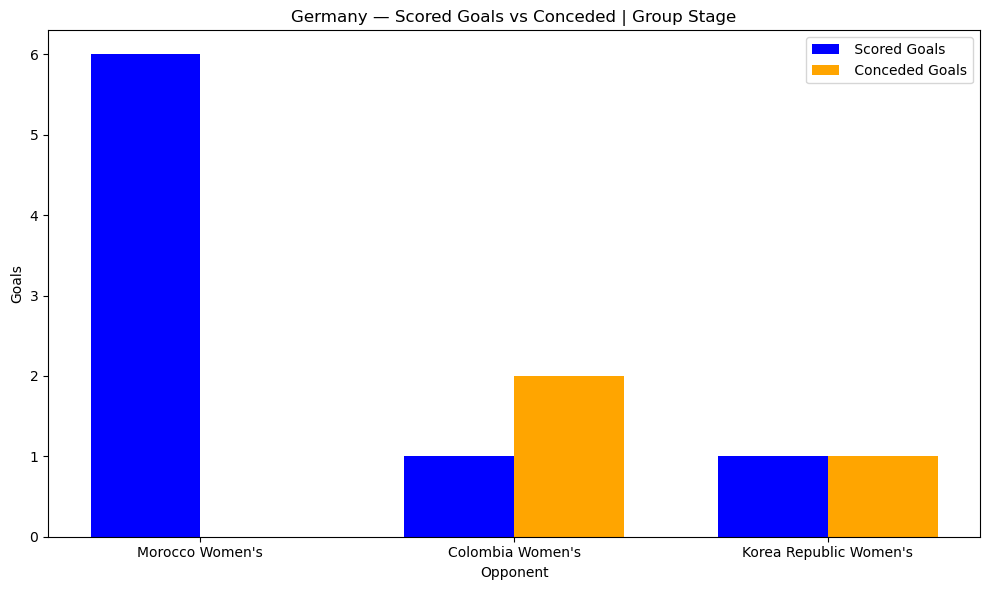

In [167]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Germany Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Germany — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Germany won one game, lost one, and tied the other two. They scored a total of 8 goals and conceded 3. 

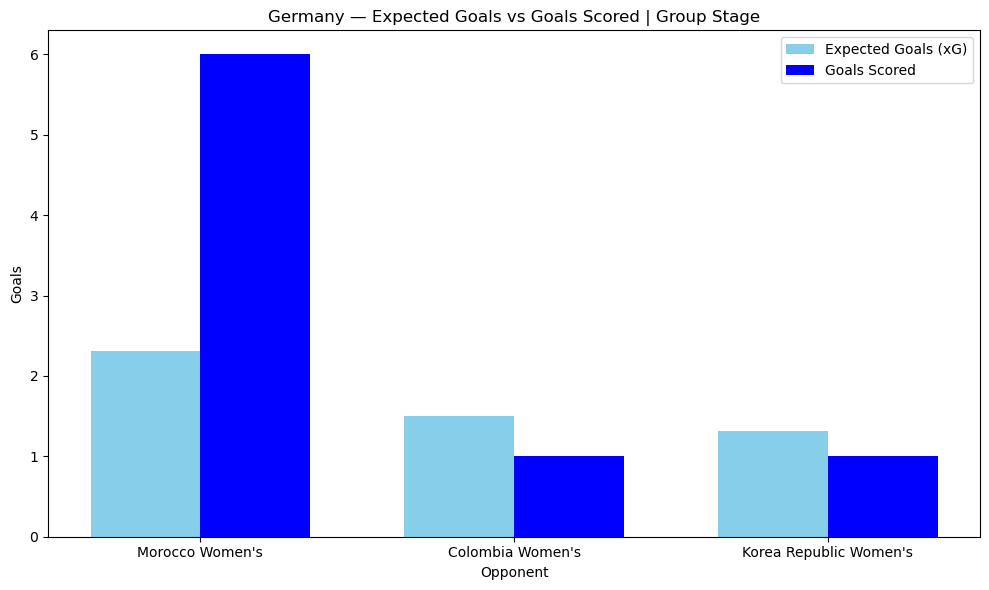

In [171]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Germany Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Germany — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Germany fell short of xG in two games, and in the game they won, they far exceeded expectations.

# Analysis GER-KOR

In [175]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Germany Women's") &
        (womens_world_cup_stats["opponent"] == "Korea Republic Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Korea Republic Women's") &
        (womens_world_cup_stats["opponent"] == "Germany Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Germany": [
        match.loc[
            match["team"] == "Germany Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "South Korea": [
        match.loc[
            match["team"] == "Korea Republic Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Germany", "South Korea"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Germany", "South Korea"]
].round(1)


# Display table

comparison

,Metric,Germany,South Korea
0,Goals,1.0,1.0
1,xG,1.3,1.0
2,Goals Minus xG,-0.3,-0.0
3,Shots,12.0,5.0
4,Shots on Target,3.0,1.0
5,Saves,1.0,2.0
6,Possession %,60.4,39.6
7,Pass Accuracy %,80.6,55.6
8,Progressive Passes,150.0,73.0
9,Progressive Carries,29.0,11.0


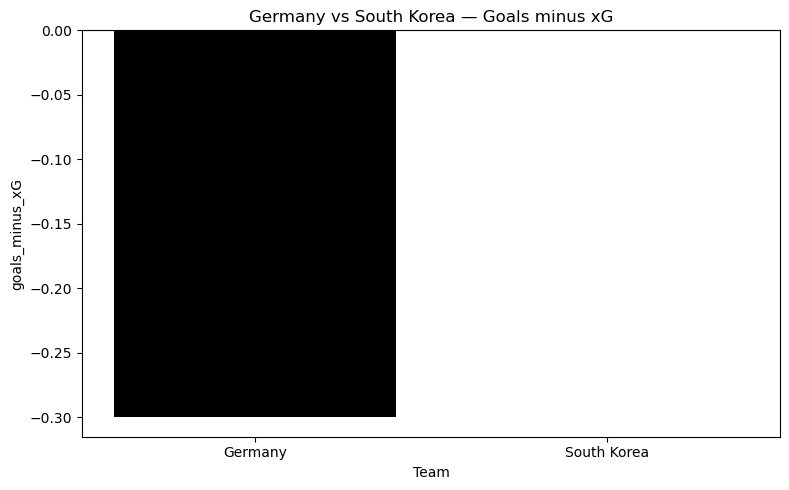

In [177]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Germany Women's") &
        (womens_world_cup_stats["opponent"] == "Korea Republic Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Korea Republic Women's") &
        (womens_world_cup_stats["opponent"] == "Germany Women's")
    )
].copy()


teams = ["Germany", "South Korea"]

goals_minus_xG = [
    match.loc[match["team"] == "Germany Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Korea Republic Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["black", "violet"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Germany vs South Korea — Goals minus xG")

plt.tight_layout()
plt.show()

Germany fell short of its xG, scoring only one goal. Looking at other metrics in the table above, this team had a hard time finishing its plays. South Korea, on the other hand, lived up to expectations by maintaining an xG minus goals of 0.

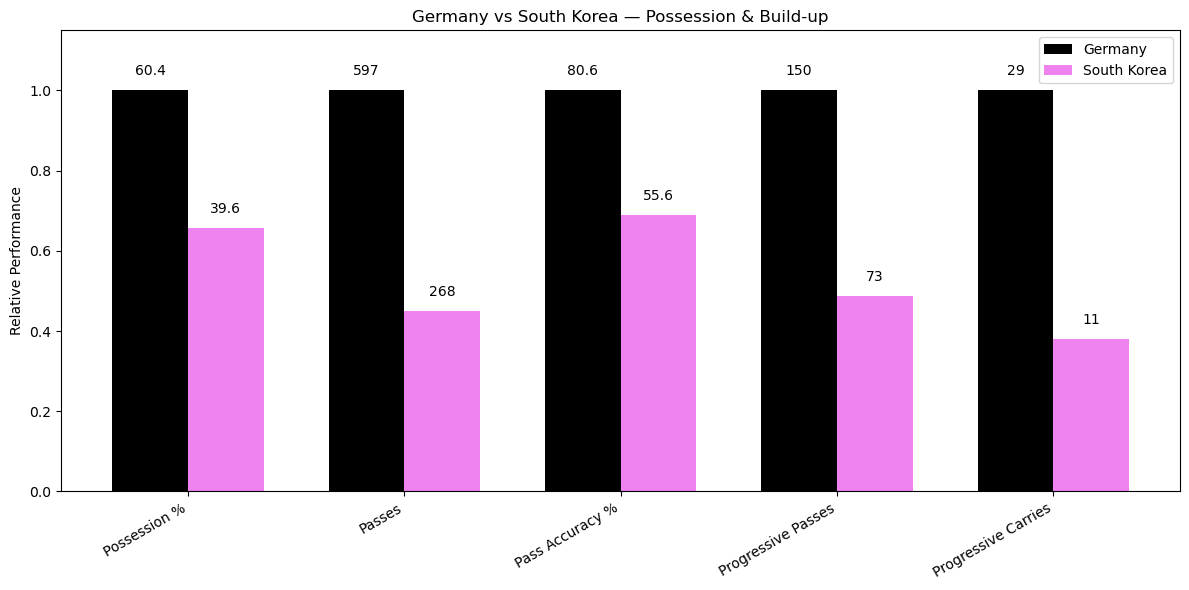

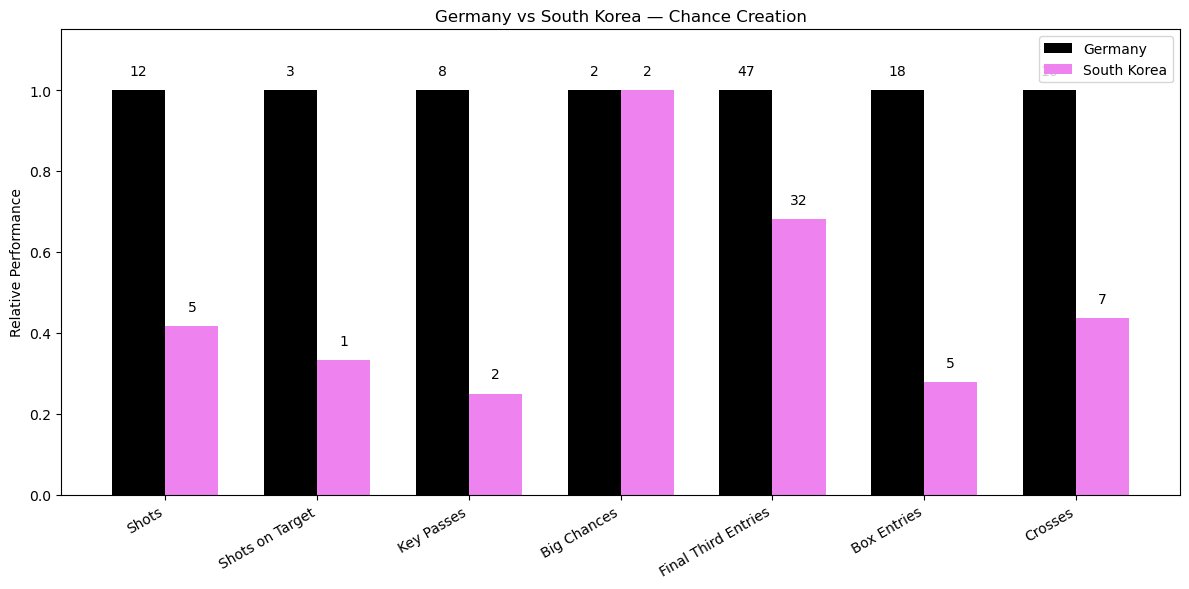

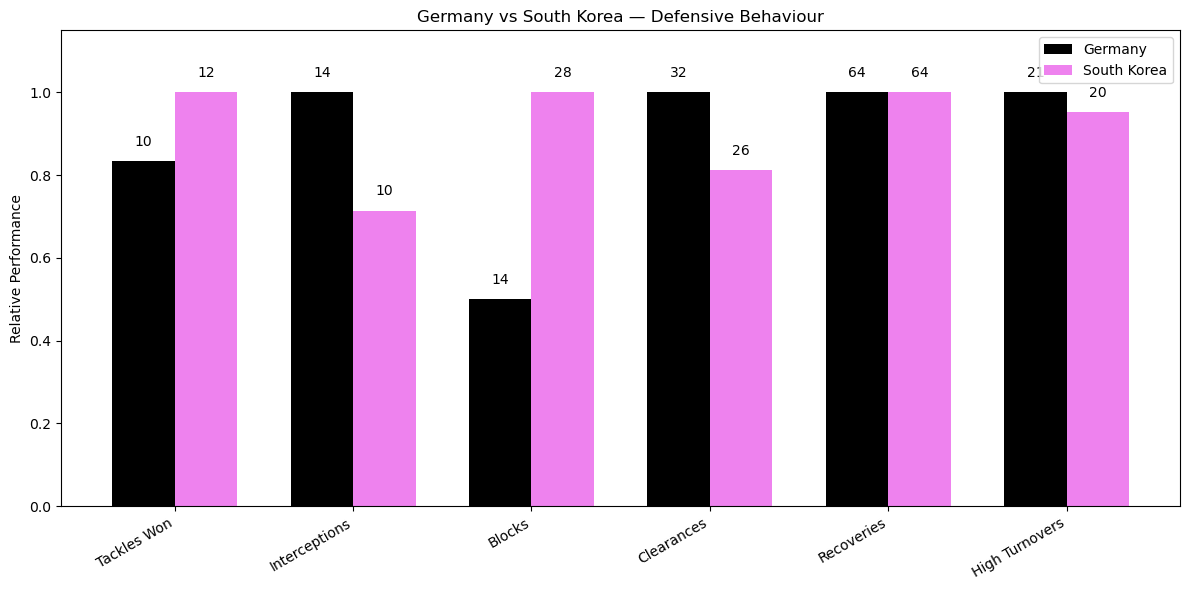

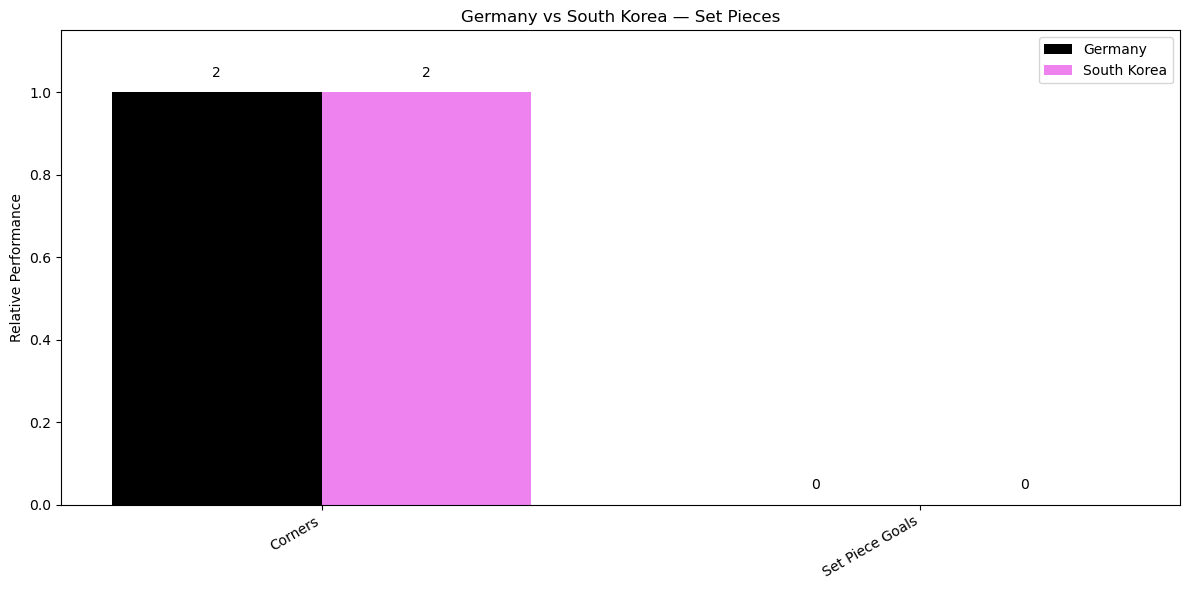

In [180]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Germany Women's") &
        (womens_world_cup_stats["opponent"] == "Korea Republic Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Korea Republic Women's") &
        (womens_world_cup_stats["opponent"] == "Germany Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Germany": "Germany Women's",
    "South Korea": "Korea Republic Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    ger_values = np.array([
        match.loc[
            match["team"] == team_names["Germany"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    kor_values = np.array([
        match.loc[
            match["team"] == team_names["South Korea"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(ger_values, kor_values)

    # Normalize
    ger_normalized = np.divide(
        ger_values,
        max_values,
        out=np.zeros_like(ger_values),
        where=max_values != 0
    )

    kor_normalized = np.divide(
        kor_values,
        max_values,
        out=np.zeros_like(kor_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_ger = plt.bar(
        x - width / 2,
        ger_normalized,
        width,
        label="Germany",
        color="black"
    )

    bars_kor = plt.bar(
        x + width / 2,
        kor_normalized,
        width,
        label="South Korea",
        color="violet"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_ger, ger_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_kor, kor_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Germany vs South Korea — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion GER-KOR

Germany dominated the game in virtually every metric related to possession, ball progression, and offensive presence, standing out particularly for its 150 progressive passes and 18 entries into the box, compared to South Korea’s mere 5. However, they once again struggled to finish: despite 12 shots and 1.3 xG, only 3 shots were on target, and the team scored just once. South Korea, though far less productive offensively, was more efficient with the few chances it managed to create and ultimately secured the draw. In this match, Germany had significant trouble converting their chances.

# Analysis South Korea's Group Stage games 

In [185]:
team = "Korea Republic Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
30,3893802,Colombia Women's,Korea Republic Women's,Group
31,3893802,Korea Republic Women's,Colombia Women's,Group
64,3893819,Korea Republic Women's,Morocco Women's,Group
65,3893819,Morocco Women's,Korea Republic Women's,Group
92,3893833,Germany Women's,Korea Republic Women's,Group
93,3893833,Korea Republic Women's,Germany Women's,Group


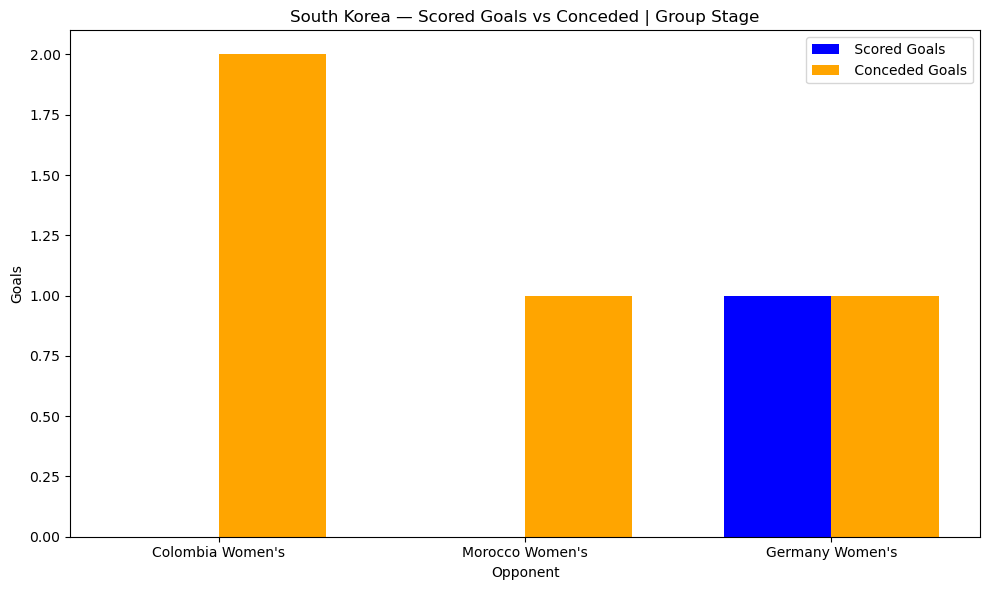

In [187]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Korea Republic Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("South Korea — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

South Korea lost two games and tied one. In total, they scored 1 goal and conceded 4.

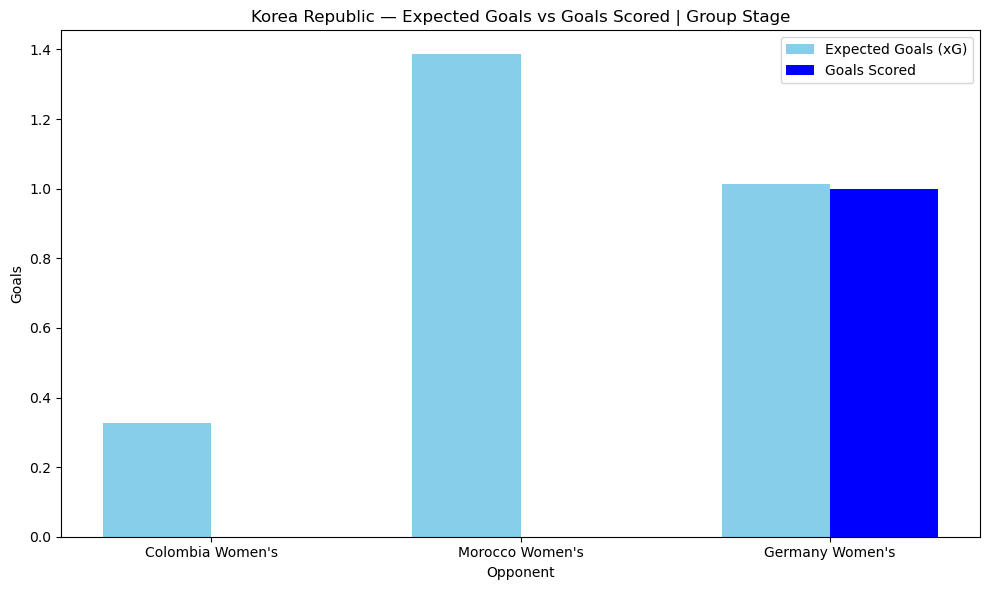

In [190]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Korea Republic Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Korea Republic — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

South Korea consistently fell short of expectations when it came to scoring opportunities. Here, one can point to a lack of conversion of opportunities as well as a lack of finishing on plays.

# Final Conclusion Group G

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


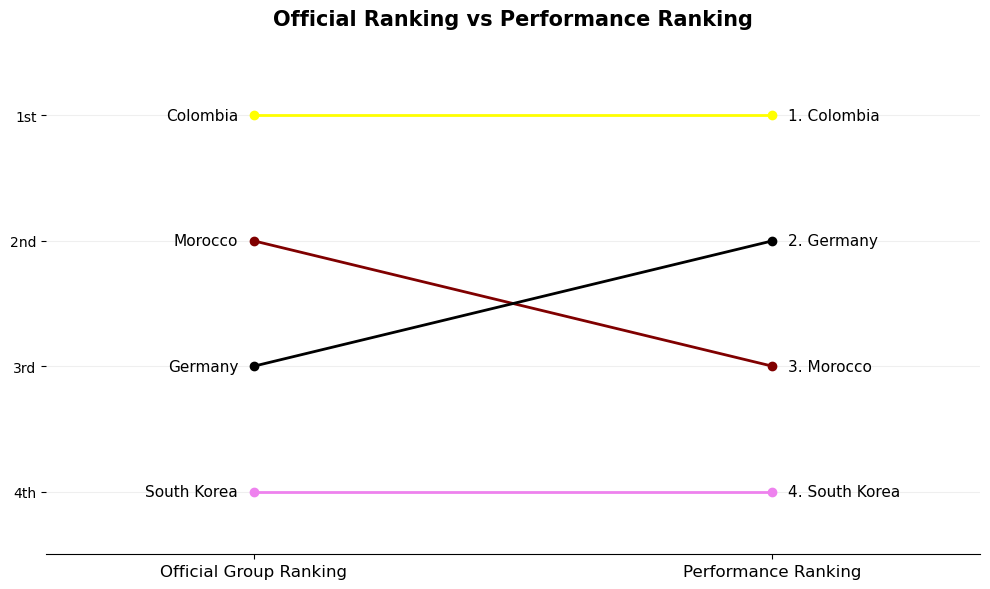

In [194]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# DATA
# ==========================================

ranking = pd.DataFrame({
    "team": ["Colombia", "Morocco", "Germany", "South Korea"],
    "official_rank": [1, 2, 3, 4],
    "performance_rank": [1, 3, 2, 4]
})

# ==========================================
# COLORS
# ==========================================

team_colors = {
    "Colombia": "yellow",
    "Morocco": "maroon",
    "Germany": "black",
    "South Korea": "violet"
}

# ==========================================
# PLOT
# ==========================================

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in ranking.iterrows():

    ax.plot(
        [0, 1],
        [row["official_rank"], row["performance_rank"]],
        marker="o",
        linewidth=2,
        color=team_colors[row["team"]]
    )

    # Official ranking
    ax.text(
        -0.03,
        row["official_rank"],
        row["team"],
        ha="right",
        va="center",
        fontsize=11
    )

    # Performance ranking
    ax.text(
        1.03,
        row["performance_rank"],
        f'{row["performance_rank"]}. {row["team"]}',
        ha="left",
        va="center",
        fontsize=11
    )

# ==========================================
# FORMATTING
# ==========================================

ax.set_xlim(-0.4, 1.4)
ax.set_ylim(4.5, 0.5)

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "Official Group Ranking",
    "Performance Ranking"
], fontsize=12)

ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["1st", "2nd", "3rd", "4th"])

ax.set_title(
    "Official Ranking vs Performance Ranking",
    fontsize=15,
    fontweight="bold",
    pad=20
)

ax.grid(axis="y", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

In the final rankings, I swapped Germany and Morocco because, even though Germany lost one game, it met several metrics that Morocco failed to meet—such as excellent ball possession and total control of the game—which translated into a very offensive strategy.
Both teams struggled with a lack of finishing in attack. 
Colombia, unlike the top teams in other groups, maintained metrics relatively close to those of its group opponents, but despite this, it displayed a consistency that the other teams lacked, thus deserving first place. 
Last place went to South Korea, which performed admirably against its opponents but was unable to translate that into a higher ranking.